📦 已載入現有資料庫 (8 件產品)。



👉 請輸入照片檔名 (q離開):  unknown3.jpg


🔍 正在分析客戶照片 (CPU 推理中)...
✨ 服務完成！本次耗時: 339.66 秒


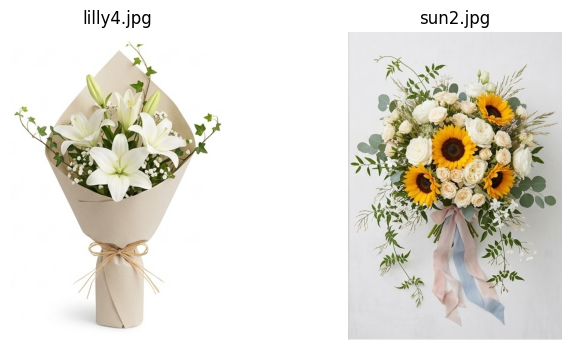

根據客戶照片描述的水生花卉類型——水生水莴（Water Lily），我發現以下兩個產品與其相似：

推薦 1：lilly4.jpg
相似理由：花瓣呈長筒型與客戶照片中的水生水莴類似。

推薦 2：sun2.jpg
相似理由：花心黃色與客戶照片中的水生水莴類似。

建議：您可以選擇 lilly4.jpg 或 sun2.jpg 這兩個產品，兩者都能夠讓您感受到水生水莴的美麗和簡約風格。



👉 請輸入照片檔名 (q離開):  q


In [1]:
import os
import json
import ollama
import re
import time
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm  # 請確保已安裝: pip install tqdm

class FlowerShopRAG:
    def __init__(self, model_name="llama3.2-vision:11b-instruct-fp16", 
                 img_db_dir="img_db", 
                 db_file="flower_db.json"):
        self.model_name = model_name
        self.img_db_dir = img_db_dir
        self.db_file = db_file
        
        # CPU 環境專用
        self.client = ollama.Client(timeout=None)
        self.database = self._load_or_build_index()

    def _load_or_build_index(self):
        if os.path.exists(self.db_file):
            with open(self.db_file, "r", encoding="utf-8") as f:
                data = json.load(f)
                print(f"📦 已載入現有資料庫 ({len(data)} 件產品)。")
                return data

        if not os.path.exists(self.img_db_dir):
            print(f"⚠️ 找不到 {self.img_db_dir} 資料夾。")
            return []

        image_files = sorted([f for f in os.listdir(self.img_db_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        
        print(f"🚀 [CPU 模式] 正在對 {len(image_files)} 張圖片建立索引...")
        print(f"💡 使用模型: {self.model_name} (請耐心等候，CPU 推理較慢)")

        flower_db = []
        total_start = time.perf_counter()

        # --- 加入 tqdm 進度條 ---
        # desc: 描述文字, unit: 單位
        pbar = tqdm(image_files, desc="分析進度", unit="張")
        
        for filename in pbar:
            path = os.path.join(self.img_db_dir, filename)
            
            # 更新進度條下方的臨時訊息
            pbar.set_postfix_str(f"正在處理: {filename}")
            
            single_start = time.perf_counter()
            
            prompt = """請分析這張照片並以 JSON 格式回傳 (繁體中文)：
            {
              "flower_type": "種類",
              "main_color": "主色調",
              "petal_shape": "花瓣細節",
              "center_detail": "花心描述",
              "visual_style": "特徵風格"
            }"""

            try:
                response = self.client.chat(
                    model=self.model_name,
                    messages=[{'role': 'user', 'content': prompt, 'images': [path]}],
                    format='json',
                    options={"temperature": 0, "num_thread": 8}
                )
                
                item_data = json.loads(response['message']['content'])
                item_data['id'] = filename
                flower_db.append(item_data)
                
                single_elapsed = time.perf_counter() - single_start
                # 在進度條下方保留歷史紀錄
                tqdm.write(f"✅ {filename} 處理完成 (耗時: {single_elapsed:.1f} 秒)")
                
            except Exception as e:
                tqdm.write(f"❌ {filename} 失敗: {str(e)[:50]}...")

        total_elapsed = time.perf_counter() - total_start
        print(f"\n✨ 索引建立完畢！總耗時: {total_elapsed/60:.2f} 分鐘")

        with open(self.db_file, "w", encoding="utf-8") as f:
            json.dump(flower_db, f, ensure_ascii=False, indent=4)
        return flower_db

    def get_recommendation(self, user_image_path):
        if not self.database: return "❌ 資料庫空。"

        print(f"🔍 正在分析客戶照片 (CPU 推理中)...")
        start_time = time.perf_counter()

        try:
            # 1. 第一步：分析使用者照片特徵
            user_res = self.client.chat(
                model=self.model_name,
                messages=[{'role': 'user', 'content': "請詳細分析這張照片中花卉的種類、顏色、形狀與風格特徵，用繁體中文回報。", 'images': [user_image_path]}],
                options={"num_thread": 8}
            )
            user_analysis = user_res['message']['content']
            
            # 2. 第二步：RAG 推薦邏輯 
            final_prompt = f"""
            你現在是『山洞口花店』的專業店員。
            
            【店內產品資料庫】：
            {json.dumps(self.database, ensure_ascii=False)}

            【客戶照片特徵描述】：
            "{user_analysis}"

            【任務指令】：
            請比對客戶照片與資料庫，找出最相似的 2 個產品。
            
            【回傳規範（極其重要）】：
            1. 必須直接使用資料庫中的 "id" (例如: lilly1.jpg) 來代表產品，禁止自創名稱。
            2. 格式請嚴格遵守：
               推薦 1：[請填入 id]
               相似理由：(請簡短說明顏色或形狀的匹配點)
               推薦 2：[請填入 id]
               相似理由：(請簡短說明風格或結構的匹配點)
            3. 最後，請用溫馨的口吻給予一段 50 字以內的繁體中文建議。
            """

            res = self.client.chat(
                model=self.model_name, 
                messages=[{'role': 'user', 'content': final_prompt}],
                options={"num_thread": 8}
            )
            
            full_response = res['message']['content']
            elapsed = time.perf_counter() - start_time
            print(f"✨ 服務完成！本次耗時: {elapsed:.2f} 秒")
            
            # 提取檔名以利顯示圖片
            # 改進的正則表達式：尋找存在於 database 中的 id
            valid_ids = [item['id'] for item in self.database]
            recommend_files = []
            for word in re.split(r'[\s，：；\[\]]+', full_response):
                if word in valid_ids and word not in recommend_files:
                    recommend_files.append(word)
            
            # 只取前兩個推薦
            recommend_files = recommend_files[:2]
            
            if recommend_files:
                self._display(recommend_files)
            else:
                print("⚠️ 警告：模型回傳內容未包含有效的產品 ID。")
                
            return full_response
        except Exception as e:
            return f"❌ 錯誤: {e}"
            return f"❌ 錯誤: {e}"

    def _display(self, filenames):
        valid_paths = [os.path.join(self.img_db_dir, f) for f in filenames if os.path.exists(os.path.join(self.img_db_dir, f))]
        if not valid_paths: return
        plt.figure(figsize=(8, 4))
        for i, p in enumerate(valid_paths):
            plt.subplot(1, len(valid_paths), i + 1)
            plt.imshow(Image.open(p))
            plt.title(os.path.basename(p))
            plt.axis('off')
        plt.show()

if __name__ == "__main__":
    assistant = FlowerShopRAG(model_name="llama3.2-vision:11b", img_db_dir="img_db", db_file="flower_db.json")
    while True:
        path = input("\n👉 請輸入照片檔名 (q離開): ").strip()
        if path.lower() == 'q': break
        if os.path.exists(path):
            print(assistant.get_recommendation(path))
        else:
            print("⚠️ 找不到檔案。")